# Handwritten Digit Recognizer — CNN + MNIST


## Install Dependencies

In [1]:
!pip install gradio tensorflow matplotlib seaborn scikit-learn pillow -q

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import gradio as gr
from PIL import Image
import os

# Style settings for all plots
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['axes.edgecolor'] = '#333355'
plt.rcParams['text.color'] = '#e0e0ff'
plt.rcParams['axes.labelcolor'] = '#e0e0ff'
plt.rcParams['xtick.color'] = '#a0a0cc'
plt.rcParams['ytick.color'] = '#a0a0cc'
plt.rcParams['grid.color'] = '#222244'
plt.rcParams['font.family'] = 'monospace'

print(' All imports successful!')

 All imports successful!


## Data Preparation

In [3]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

num_classes = 10
input_shape = (28, 28, 1)

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Expand dims for CNN input
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# Keep raw labels for evaluation, one-hot for training
y_train_raw = y_train.copy()
y_test_raw  = y_test.copy()
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test, num_classes)

print(f' Train: {x_train.shape} | Test: {x_test.shape}')
print(f'   Label distribution: {np.bincount(y_train_raw)}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)
   Label distribution: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


##  Data Preview Plot

/tmp/ipykernel_7074/1336900581.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')


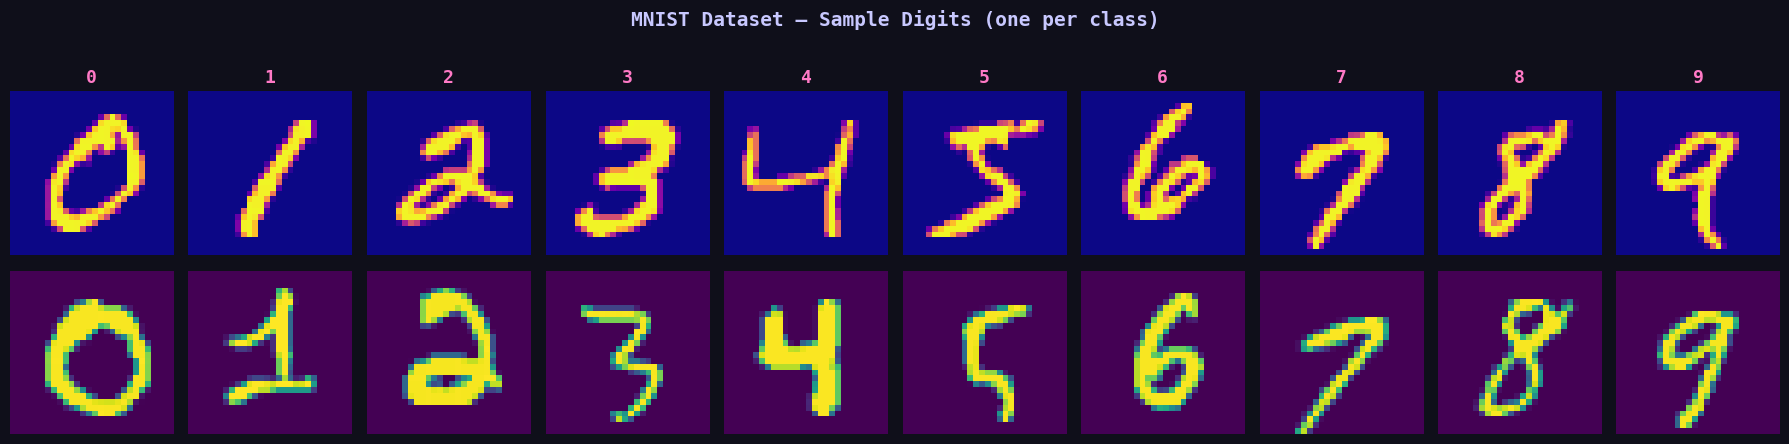

 Data preview saved.


In [6]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4.5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('MNIST Dataset — Sample Digits (one per class)',
             fontsize=14, color='#c8c8ff', fontweight='bold', y=1.02)

cmap = plt.cm.get_cmap('plasma')
for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]
    for row in range(2):
        ax = axes[row][digit]
        if row == 0:
            ax.imshow(x_train[idx].squeeze(), cmap='plasma', interpolation='nearest')
            ax.set_title(f'{digit}', color='#ff79c6', fontsize=13, fontweight='bold')
        else:
            idx2 = np.where(y_train_raw == digit)[0][5]
            ax.imshow(x_train[idx2].squeeze(), cmap='viridis', interpolation='nearest')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('#555588')

plt.tight_layout()
plt.savefig('plot_data_preview.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(' Data preview saved.')

## Build Improved CNN Model

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='mnist_cnn_v2')

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "mnist_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

## Train the Model

In [5]:
MODEL_PATH = 'mnist_model.keras'

if os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    print(f' Model loaded from {MODEL_PATH}')
    # Dummy history for plot compatibility
    history = None
else:
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    ]

    history = model.fit(
        x_train, y_train,
        batch_size=128,
        epochs=15,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )

score = model.evaluate(x_test, y_test, verbose=0)
print(f'\n Test Accuracy : {score[1]*100:.2f}%')
print(f' Test Loss     : {score[0]:.4f}')

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8634 - loss: 0.4525
Epoch 1: val_accuracy improved from None to 0.81700, saving model to mnist_model.keras

Epoch 1: finished saving model to mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9363 - loss: 0.2073 - val_accuracy: 0.8170 - val_loss: 0.5808 - learning_rate: 0.0010
Epoch 2/15
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9770 - loss: 0.0735
Epoch 2: val_accuracy improved from 0.81700 to 0.98733, saving model to mnist_model.keras

Epoch 2: finished saving model to mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9786 - loss: 0.0687 - val_accuracy: 0.9873 - val_loss: 0.0428 - learning_rate: 0.0010
Epoch 3/15
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9851 - loss: 0.0506
Epoch 3: val_accuracy improved from 0.98733 to 0.98983, saving model to mnist_model.keras

Epoch 3: finished saving model to mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 

## Training Curves Plot

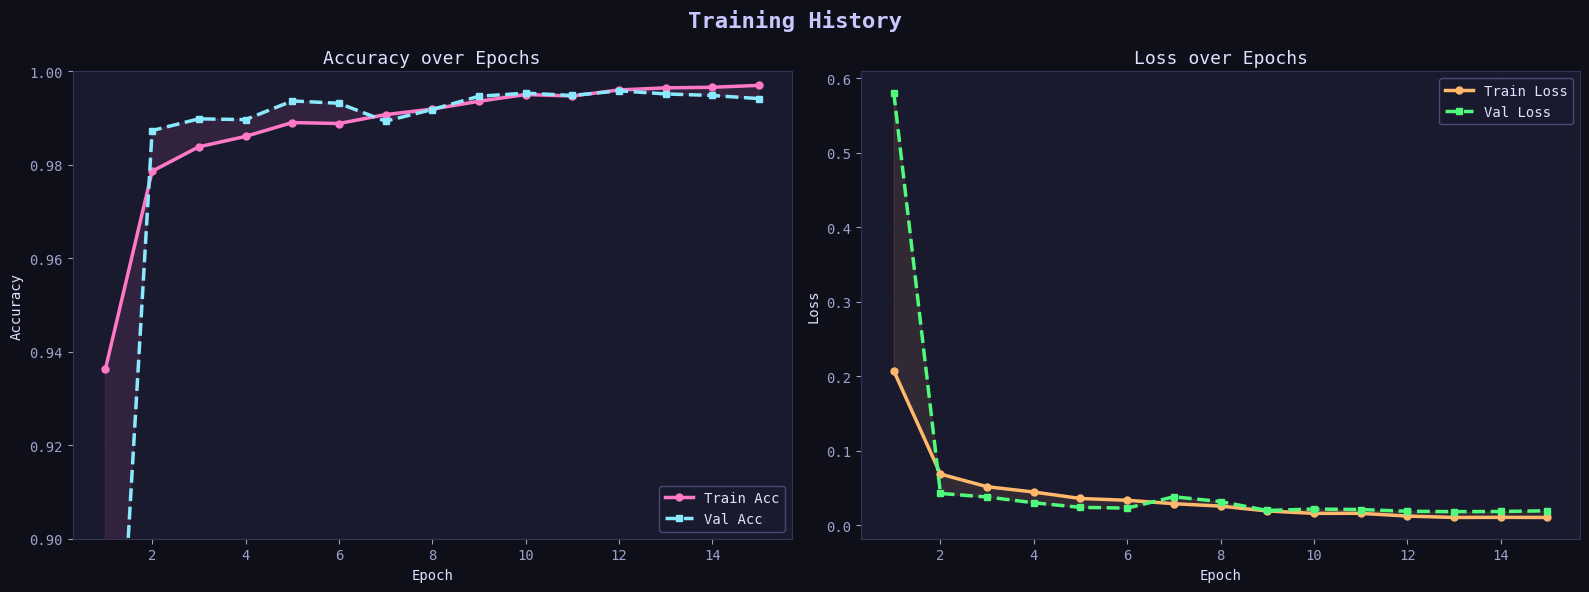

 Training curves saved.


In [7]:
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('Training History', fontsize=16, color='#c8c8ff', fontweight='bold')

    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # --- Accuracy Plot ---
    ax = axes[0]
    ax.plot(epochs_range, history.history['accuracy'],
            color='#ff79c6', linewidth=2.5, marker='o', markersize=5, label='Train Acc')
    ax.plot(epochs_range, history.history['val_accuracy'],
            color='#8be9fd', linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Val Acc')
    ax.fill_between(epochs_range, history.history['accuracy'],
                    history.history['val_accuracy'], alpha=0.1, color='#ff79c6')
    ax.set_title('Accuracy over Epochs', color='#e0e0ff', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(facecolor='#1a1a2e', edgecolor='#555588', labelcolor='#e0e0ff')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.9, 1.0])

    # --- Loss Plot ---
    ax2 = axes[1]
    ax2.plot(epochs_range, history.history['loss'],
             color='#ffb86c', linewidth=2.5, marker='o', markersize=5, label='Train Loss')
    ax2.plot(epochs_range, history.history['val_loss'],
             color='#50fa7b', linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Val Loss')
    ax2.fill_between(epochs_range, history.history['loss'],
                     history.history['val_loss'], alpha=0.1, color='#ffb86c')
    ax2.set_title('Loss over Epochs', color='#e0e0ff', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(facecolor='#1a1a2e', edgecolor='#555588', labelcolor='#e0e0ff')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('plot_training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print(' Training curves saved.')
else:
    print('ℹ  Model was loaded from file — no training history available.')

##  Confusion Matrix

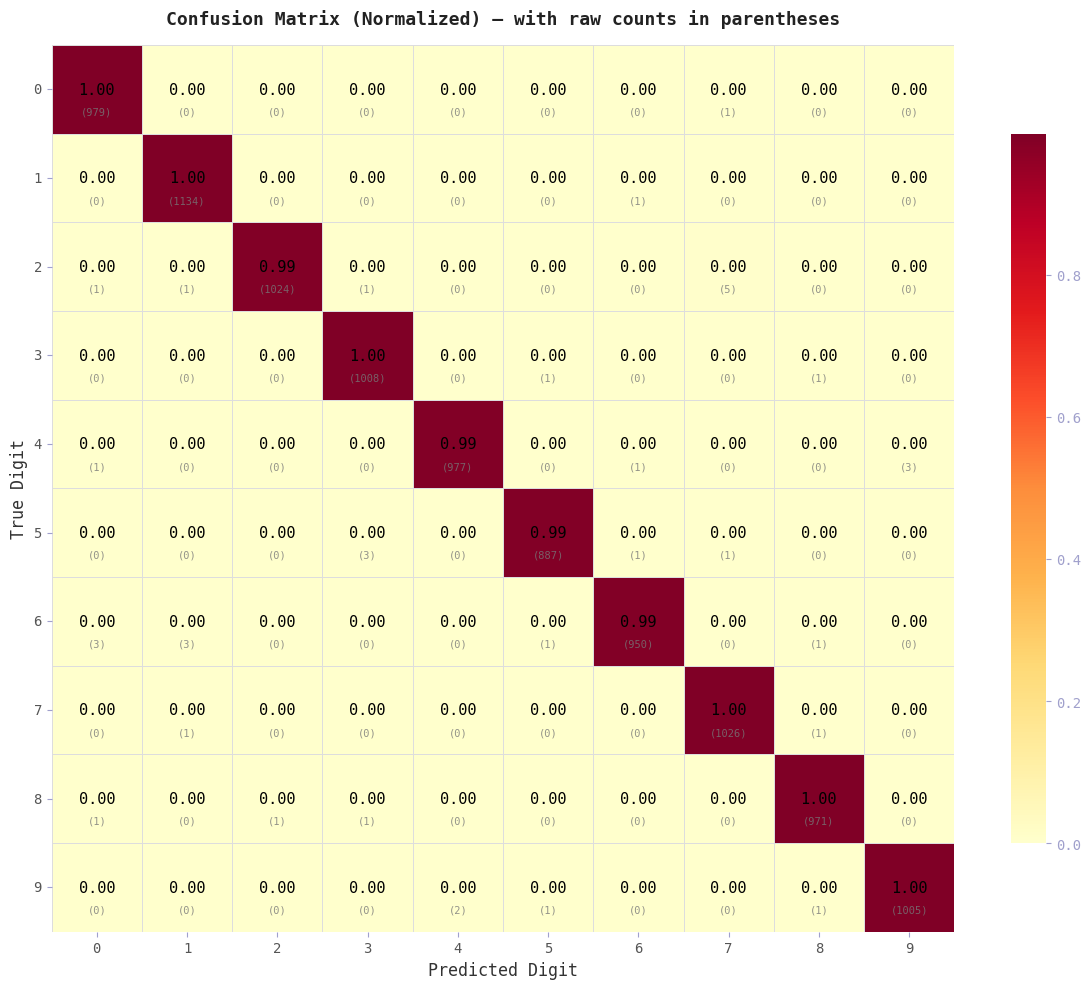

Confusion matrix saved.


In [10]:
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test_raw, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f8f8')
cmap = 'YlOrRd'
title_color = '#222222'
label_color = '#333333'
tick_color = '#555555'
count_color = '#777777'

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    cmap=cmap,
    ax=ax,
    linewidths=0.5,
    linecolor='#dddddd',
    annot_kws={'size': 11, 'color': 'black'},
    cbar_kws={'shrink': 0.8}
)

for i in range(10):
    for j in range(10):
        ax.text(j + 0.5, i + 0.75, f'({cm[i,j]})',
                ha='center', va='center', fontsize=7.5,
                color=count_color, alpha=0.8)

ax.set_title('Confusion Matrix (Normalized) — with raw counts in parentheses',
             color=title_color, fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Digit', color=label_color, fontsize=12)
ax.set_ylabel('True Digit', color=label_color, fontsize=12)
ax.set_xticklabels(range(10), color=tick_color)
ax.set_yticklabels(range(10), color=tick_color, rotation=0)

plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Confusion matrix saved.')

##  Per-Class Accuracy Bar Chart

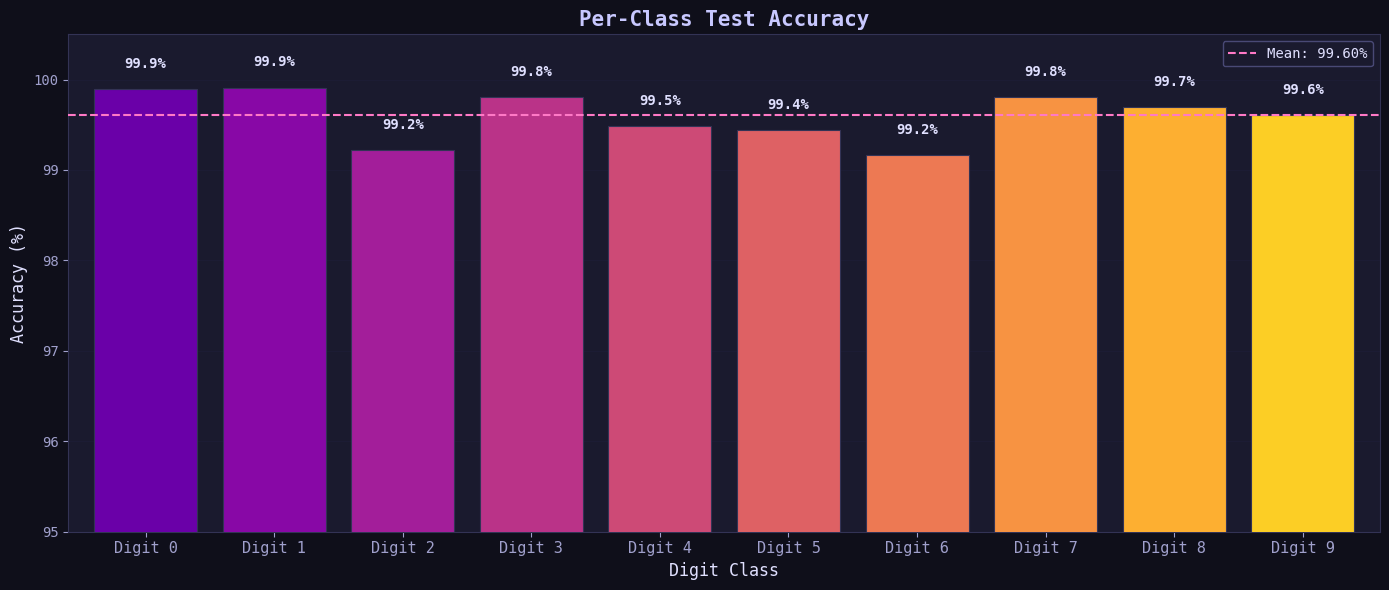

Per-class accuracy saved.

 Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      1.00      1.00      1010
           4       1.00      0.99      1.00       982
           5       1.00      0.99      1.00       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       1.00      1.00      1.00      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [12]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = plt.cm.plasma(np.linspace(0.2, 0.9, 10))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

bars = ax.bar(range(10), per_class_acc * 100, color=colors,
              edgecolor='#333355', linewidth=0.8, zorder=3)

# Annotate bars
for i, (bar, acc) in enumerate(zip(bars, per_class_acc)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc*100:.1f}%', ha='center', va='bottom',
            color='#e0e0ff', fontsize=10, fontweight='bold')

ax.axhline(y=np.mean(per_class_acc)*100, color='#ff79c6',
           linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(per_class_acc)*100:.2f}%', zorder=4)

ax.set_xlim(-0.6, 9.6)
ax.set_ylim([95, 100.5])
ax.set_xticks(range(10))
ax.set_xticklabels([f'Digit {i}' for i in range(10)], fontsize=11)
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Test Accuracy', fontsize=15, color='#c8c8ff', fontweight='bold')
ax.legend(facecolor='#1a1a2e', edgecolor='#555588', labelcolor='#e0e0ff')
ax.grid(True, axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('plot_per_class_accuracy.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Per-class accuracy saved.')
print(f'\n Classification Report:\n')
print(classification_report(y_test_raw, y_pred, target_names=[str(i) for i in range(10)]))

##  Misclassified Samples

Total misclassified: 39 / 10000 (0.39%)


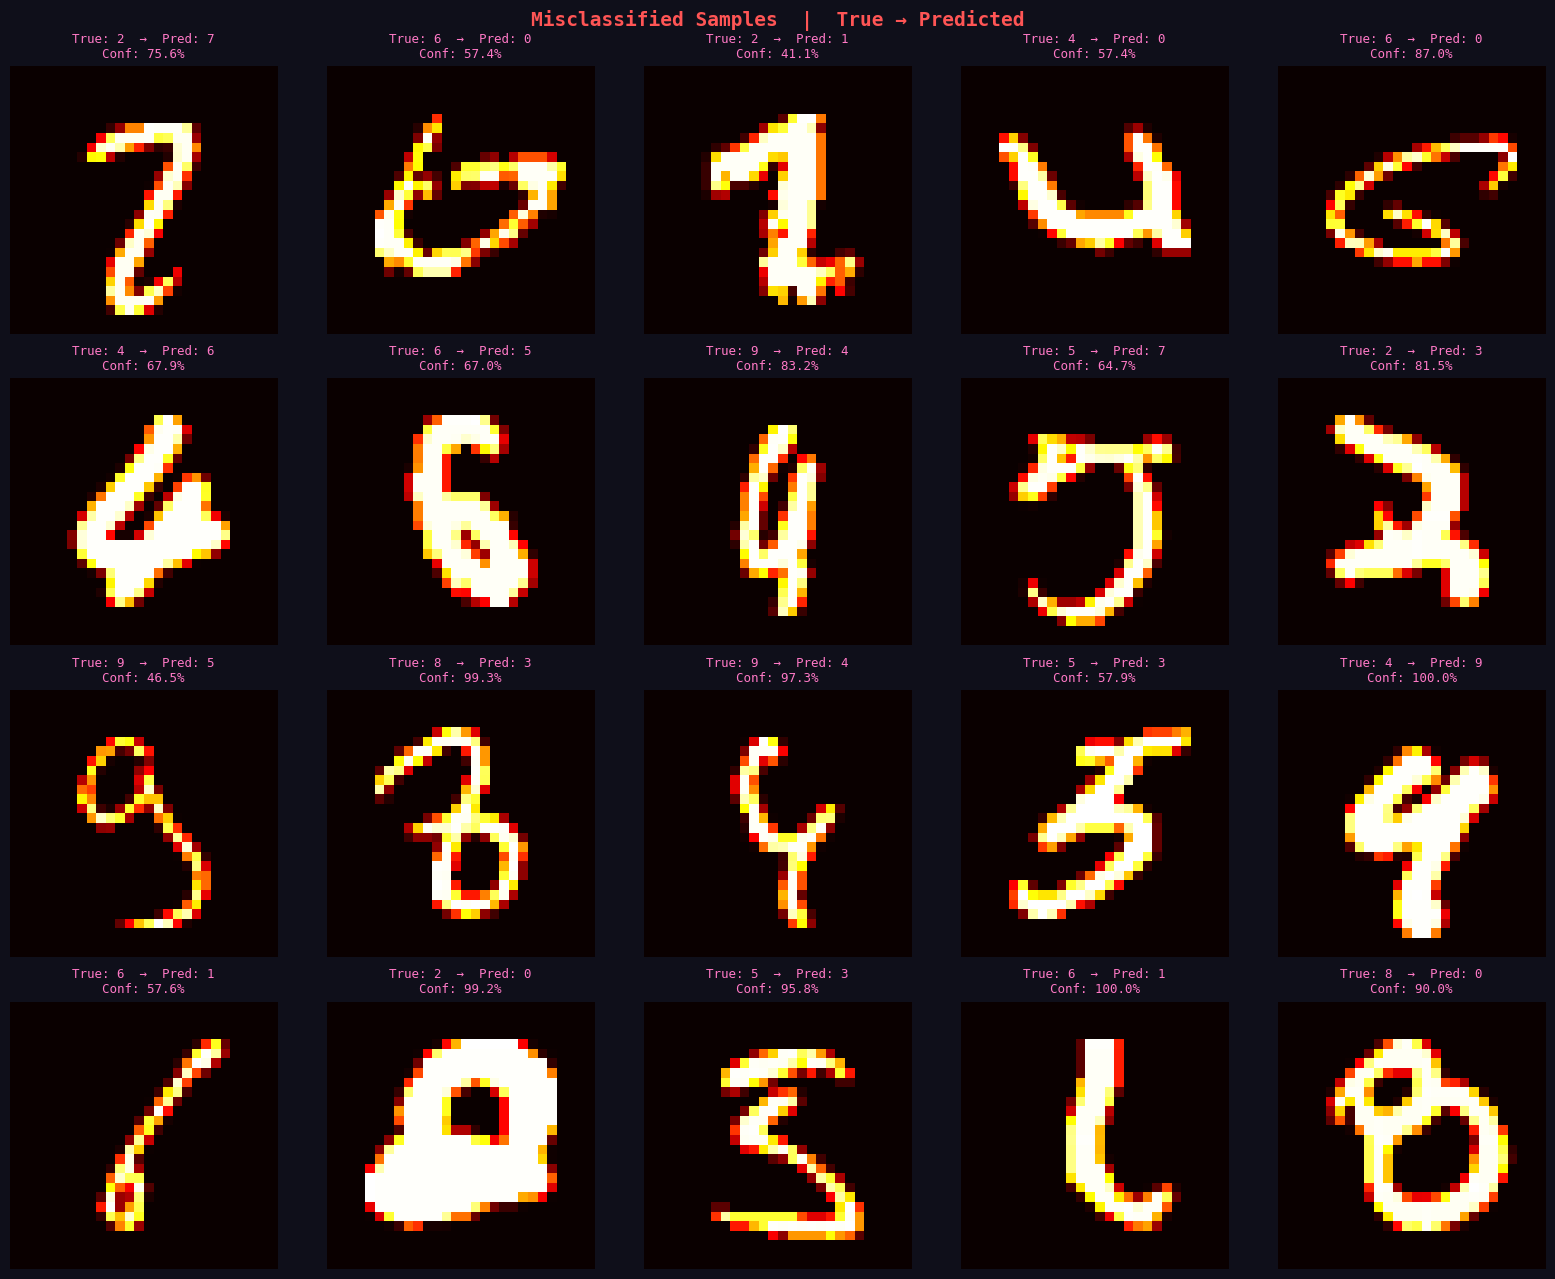

Misclassified samples plot saved.


In [13]:
wrong_idx = np.where(y_pred != y_test_raw)[0]
print(f'Total misclassified: {len(wrong_idx)} / {len(y_test_raw)} ({len(wrong_idx)/len(y_test_raw)*100:.2f}%)')

# Show 20 misclassified examples
sample = wrong_idx[:20]
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle(f'Misclassified Samples  |  True → Predicted',
             fontsize=14, color='#ff5555', fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(sample):
        idx = sample[i]
        probs = model.predict(x_test[idx:idx+1], verbose=0)[0]
        conf = np.max(probs) * 100
        ax.imshow(x_test[idx].squeeze(), cmap='hot', interpolation='nearest')
        ax.set_title(f'True: {y_test_raw[idx]}  →  Pred: {y_pred[idx]}\nConf: {conf:.1f}%',
                     color='#ff79c6', fontsize=9)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('#ff5555')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('plot_misclassified.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Misclassified samples plot saved.')

##  Gradio App (Live Digit Recognition)

In [14]:
def predict_digit(image):
    if image is None:
        return None, ' Please draw or upload a digit.'
    try:
        img = Image.fromarray(image).convert('L')
        img = img.resize((28, 28), Image.LANCZOS)
        img_array = np.array(img)

        # Smart inversion: MNIST uses white digit on black background
        if np.mean(img_array) > 127:
            img_array = 255 - img_array

        processed = img_array.astype('float32') / 255.0
        processed = processed.reshape(1, 28, 28, 1)

        probs = model.predict(processed, verbose=0)[0]
        predicted = int(np.argmax(probs))
        confidence = float(np.max(probs)) * 100

        # Build probability bar chart
        fig, axes = plt.subplots(1, 2, figsize=(10, 4),
                                  gridspec_kw={'width_ratios': [1, 2.5]})
        fig.patch.set_facecolor('#0f0f1a')

        # Left: processed image
        axes[0].imshow(img_array, cmap='plasma', interpolation='nearest')
        axes[0].set_title(f'Input (28×28)', color='#a0a0cc', fontsize=10)
        axes[0].axis('off')

        # Right: probability bars
        bar_colors = ['#555588'] * 10
        bar_colors[predicted] = '#ff79c6'
        axes[1].barh(range(10), probs * 100, color=bar_colors,
                     edgecolor='#222244', height=0.7)
        axes[1].set_yticks(range(10))
        axes[1].set_yticklabels([f'Digit {i}' for i in range(10)],
                                 color='#e0e0ff', fontsize=10)
        axes[1].set_xlabel('Probability (%)', color='#a0a0cc')
        axes[1].set_xlim([0, 100])
        axes[1].set_title(f' Predicted: {predicted}  |  Confidence: {confidence:.1f}%',
                          color='#ff79c6', fontsize=12, fontweight='bold')
        axes[1].set_facecolor('#1a1a2e')
        axes[1].grid(True, axis='x', alpha=0.2)
        for spine in axes[1].spines.values():
            spine.set_edgecolor('#333355')

        # Annotate bars with values
        for i, p in enumerate(probs):
            if p * 100 > 1:
                axes[1].text(p * 100 + 0.5, i, f'{p*100:.1f}%',
                             va='center', color='#e0e0ff', fontsize=9)

        plt.tight_layout()
        plt.close(fig)

        result_text = (
            f' Predicted Digit: {predicted}\n'
            f' Confidence: {confidence:.2f}%\n'
            f' Runner-up: Digit {np.argsort(probs)[-2]} ({probs[np.argsort(probs)[-2]]*100:.1f}%)'
        )
        return fig, result_text

    except Exception as e:
        return None, f' Error: {str(e)}'


print('predict_digit function ready.')

predict_digit function ready.


In [18]:
css = """
body { background: #0f0f1a !important; font-family: monospace; }
.gradio-container { background: #0f0f1a !important; }
h1 { color: #ff79c6 !important; }
"""

with gr.Blocks(theme=gr.themes.Base(), css=css, title='Digit Recognizer') as demo:
    gr.Markdown('# ✍️ Handwritten Digit Recognizer')
    gr.Markdown('Draw a digit or upload an image — the CNN will predict it in real time.')

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label='Draw or Upload a Digit',
                type='numpy',
                sources=['upload'],
                height=280
            )
            predict_btn = gr.Button(' ℘ Predict', variant='primary')
            clear_btn    = gr.ClearButton([image_input], value=' 🗑️ Clear')

        with gr.Column(scale=2):
            output_plot = gr.Plot(label='Prediction Visualization')
            output_text = gr.Textbox(label='Result', lines=4, interactive=False)

    predict_btn.click(
        predict_digit,
        inputs=image_input,
        outputs=[output_plot, output_text]
    )

    gr.Markdown('---')
    gr.Markdown('**Model:** CNN (2×Conv+BN+MaxPool+Dropout → Dense 256 → Softmax) | **Dataset:** MNIST | **Framework:** Keras/TensorFlow')

demo.launch(share=True)

/tmp/ipykernel_1676/421405842.py:7: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Base(), css=css, title='Digit Recognizer') as demo:
/tmp/ipykernel_1676/421405842.py:7: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Base(), css=css, title='Digit Recognizer') as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f65ea615242fb3d21e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
